# Improving RAG Retrieval Quality via Hybrid Sparse-Dense Retrieval
**NLP Assignment 3 — Group Project**

**Team Members**
- Member 1: Yuchang Zhang (25678259)
- Member 2: [Name] ([Student ID])
- Member 3: [Name] ([Student ID])
- Member 4: [Name] ([Student ID])

This notebook evaluates **Hybrid Sparse-Dense Retrieval** as a retrieval-stage solution
for improving document selection in RAG (Retrieval-Augmented Generation) pipelines.
Three retrieval methods are compared:
- **BM25** — sparse/lexical baseline
- **Dense Retrieval** — semantic embedding-based baseline
- **Hybrid RRF** — proposed solution combining BM25 + Dense via Reciprocal Rank Fusion

Dataset: SQuAD v1.1 full validation set (10,570 questions, 2,067 unique documents)


## 1. Setup

In [1]:
!pip install rank_bm25 sentence-transformers faiss-cpu datasets matplotlib seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 31.5 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
from datasets import load_dataset
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
import faiss
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("All imports OK")

All imports OK


## 2. Load Dataset & Build Corpus

In [3]:
# Load SQuAD v1.1 full validation set (10,570 questions)
dataset = load_dataset("rajpurkar/squad", split="validation")

# Deduplicate contexts to form the document corpus
contexts = list(dict.fromkeys(dataset['context']))  # preserves order, removes duplicates
context_to_id = {ctx: i for i, ctx in enumerate(contexts)}

# Build QA pairs with ground truth context index
qa_pairs = [
    {
        'question': item['question'],
        'gold_id': context_to_id[item['context']]
    }
    for item in dataset
]

print(f"Corpus size:        {len(contexts)} unique documents")
print(f"Number of queries:  {len(qa_pairs)} questions")
print(f"\nExample document (truncated):")
print(contexts[0][:300], "...")
print(f"\nExample question: {qa_pairs[0]['question']}")

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

plain_text/validation-00000-of-00001.par(…):   0%|          | 0.00/1.82M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

Corpus size:        2067 unique documents
Number of queries:  10570 questions

Example document (truncated):
Super Bowl 50 was an American football game to determine the champion of the National Football League (NFL) for the 2015 season. The American Football Conference (AFC) champion Denver Broncos defeated the National Football Conference (NFC) champion Carolina Panthers 24–10 to earn their third Super B ...

Example question: Which NFL team represented the AFC at Super Bowl 50?


## 3. Retriever 1 — BM25 (Sparse Retrieval)

BM25 (Best Match 25) is a probabilistic retrieval model based on TF-IDF weighting.
It scores documents using term frequency saturation and document length normalisation:

$$\text{score}(D, Q) = \sum_{i=1}^{n} \text{IDF}(q_i) \cdot \frac{f(q_i, D) \cdot (k_1 + 1)}{f(q_i, D) + k_1 \cdot (1 - b + b \cdot \frac{|D|}{\text{avgdl}})}$$

In [4]:
def tokenize(text):
    return text.lower().split()

tokenized_corpus = [tokenize(ctx) for ctx in contexts]
bm25 = BM25Okapi(tokenized_corpus)

def retrieve_bm25(question, k=10):
    scores = bm25.get_scores(tokenize(question))
    return np.argsort(scores)[::-1][:k].tolist()

# Quick sanity check
test_q = qa_pairs[0]['question']
test_gold = qa_pairs[0]['gold_id']
bm25_top5 = retrieve_bm25(test_q, k=5)
print(f"Question: {test_q}")
print(f"Gold context id: {test_gold}")
print(f"BM25 top-5 ids:  {bm25_top5}")
print(f"Gold in top-5?   {test_gold in bm25_top5}")

Question: Which NFL team represented the AFC at Super Bowl 50?
Gold context id: 0
BM25 top-5 ids:  [22, 1, 7, 24, 29]
Gold in top-5?   False


## 4. Retriever 2 — Dense Retrieval (Semantic Embedding)

Dense retrieval encodes both queries and documents into a shared embedding space using a
pre-trained bi-encoder (all-MiniLM-L6-v2). Retrieval is performed via cosine similarity search
using FAISS for efficient approximate nearest-neighbour lookup.

In [5]:
# Load bi-encoder model (~80MB, fast on Colab T4)
encoder = SentenceTransformer('all-MiniLM-L6-v2')

print("Encoding corpus documents...")
corpus_embeddings = encoder.encode(
    contexts,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True  # L2 normalise so inner product == cosine similarity
).astype(np.float32)

# Build FAISS flat inner-product index
dim = corpus_embeddings.shape[1]
faiss_index = faiss.IndexFlatIP(dim)
faiss_index.add(corpus_embeddings)

print(f"\nEmbedding dimension: {dim}")
print(f"FAISS index size:    {faiss_index.ntotal} vectors")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding corpus documents...


Batches:   0%|          | 0/33 [00:00<?, ?it/s]


Embedding dimension: 384
FAISS index size:    2067 vectors


In [6]:
def retrieve_dense(question, k=10):
    q_emb = encoder.encode([question], normalize_embeddings=True).astype(np.float32)
    _, ids = faiss_index.search(q_emb, k)
    return ids[0].tolist()

# Sanity check
dense_top5 = retrieve_dense(test_q, k=5)
print(f"Question: {test_q}")
print(f"Dense top-5 ids: {dense_top5}")
print(f"Gold in top-5?   {test_gold in dense_top5}")

Question: Which NFL team represented the AFC at Super Bowl 50?
Dense top-5 ids: [0, 1, 22, 8, 16]
Gold in top-5?   True


## 5. Retriever 3 — Hybrid (Reciprocal Rank Fusion)

Reciprocal Rank Fusion (RRF) combines ranked lists from multiple retrievers without
requiring score normalisation. Each document's fused score is:

$$\text{RRF}(d) = \sum_{r \in R} \frac{1}{k + \text{rank}_r(d)}$$

where $k=60$ is a smoothing constant and $R$ is the set of rankers.

In [7]:
CANDIDATE_K = 50   # retrieve top-50 candidates from each retriever before fusion
RRF_K = 60         # RRF smoothing constant

def retrieve_hybrid(question, k=10):
    bm25_ranked  = retrieve_bm25(question, k=CANDIDATE_K)
    dense_ranked = retrieve_dense(question, k=CANDIDATE_K)

    rrf_scores = {}
    for rank, doc_id in enumerate(bm25_ranked):
        rrf_scores[doc_id] = rrf_scores.get(doc_id, 0) + 1.0 / (RRF_K + rank + 1)
    for rank, doc_id in enumerate(dense_ranked):
        rrf_scores[doc_id] = rrf_scores.get(doc_id, 0) + 1.0 / (RRF_K + rank + 1)

    sorted_ids = sorted(rrf_scores, key=rrf_scores.get, reverse=True)
    return sorted_ids[:k]

# Sanity check
hybrid_top5 = retrieve_hybrid(test_q, k=5)
print(f"Question:         {test_q}")
print(f"Hybrid top-5 ids: {hybrid_top5}")
print(f"Gold in top-5?    {test_gold in hybrid_top5}")

Question:         Which NFL team represented the AFC at Super Bowl 50?
Hybrid top-5 ids: [22, 1, 7, 0, 16]
Gold in top-5?    True


## 6. Evaluation

We evaluate all three retrievers on the **full SQuAD v1.1 validation set**
(10,570 questions, 2,067 unique documents). Metrics:
- **Recall@k** — proportion of questions where the gold document appears in the top-k results
- **MRR** (Mean Reciprocal Rank) — average of 1/rank of the first correct result

BM25 and Dense serve as baselines; Hybrid RRF is the proposed solution.

In [8]:
K_VALUES = [1, 3, 5, 10]

def evaluate(retrieve_fn, qa_pairs, k_values=K_VALUES, name=""):
    hits = {k: 0 for k in k_values}
    mrr_total = 0.0

    for qa in tqdm(qa_pairs, desc=f"Evaluating {name}"):
        retrieved = retrieve_fn(qa['question'], k=max(k_values))
        gold = qa['gold_id']

        for k in k_values:
            if gold in retrieved[:k]:
                hits[k] += 1

        if gold in retrieved:
            mrr_total += 1.0 / (retrieved.index(gold) + 1)

    n = len(qa_pairs)
    metrics = {f"Recall@{k}": hits[k] / n for k in k_values}
    metrics["MRR"] = mrr_total / n
    return metrics

print("Running evaluation — this takes ~2-3 minutes...")

Running evaluation — this takes ~2-3 minutes...


In [9]:
bm25_metrics   = evaluate(retrieve_bm25,   qa_pairs, name="BM25")
dense_metrics  = evaluate(retrieve_dense,  qa_pairs, name="Dense")
hybrid_metrics = evaluate(retrieve_hybrid, qa_pairs, name="Hybrid")

Evaluating Hybrid: 100%|██████████| 10570/10570 [05:59<00:00, 29.42it/s]


## 7. Results — Block 1: Main Experiment

Full validation set evaluation (10,570 questions, 2,067 documents).

In [10]:
results_df = pd.DataFrame({
    'BM25':   bm25_metrics,
    'Dense':  dense_metrics,
    'Hybrid': hybrid_metrics
}).T

print("="*55)
print("        Retrieval Evaluation Results (SQuAD subset)")
print("="*55)
print(results_df.round(4).to_string())
print("="*55)

# Highlight best per column
print("\nBest per metric:")
for col in results_df.columns:
    best = results_df[col].idxmax()
    print(f"  {col}: {best} ({results_df.loc[best, col]:.4f})")

        Retrieval Evaluation Results (SQuAD subset)
        Recall@1  Recall@3  Recall@5  Recall@10     MRR
BM25      0.6026    0.7328    0.7764     0.8289  0.6787
Dense     0.6251    0.8077    0.8640     0.9172  0.7270
Hybrid    0.6700    0.8215    0.8749     0.9305  0.7574

Best per metric:
  Recall@1: Hybrid (0.6700)
  Recall@3: Hybrid (0.8215)
  Recall@5: Hybrid (0.8749)
  Recall@10: Hybrid (0.9305)
  MRR: Hybrid (0.7574)


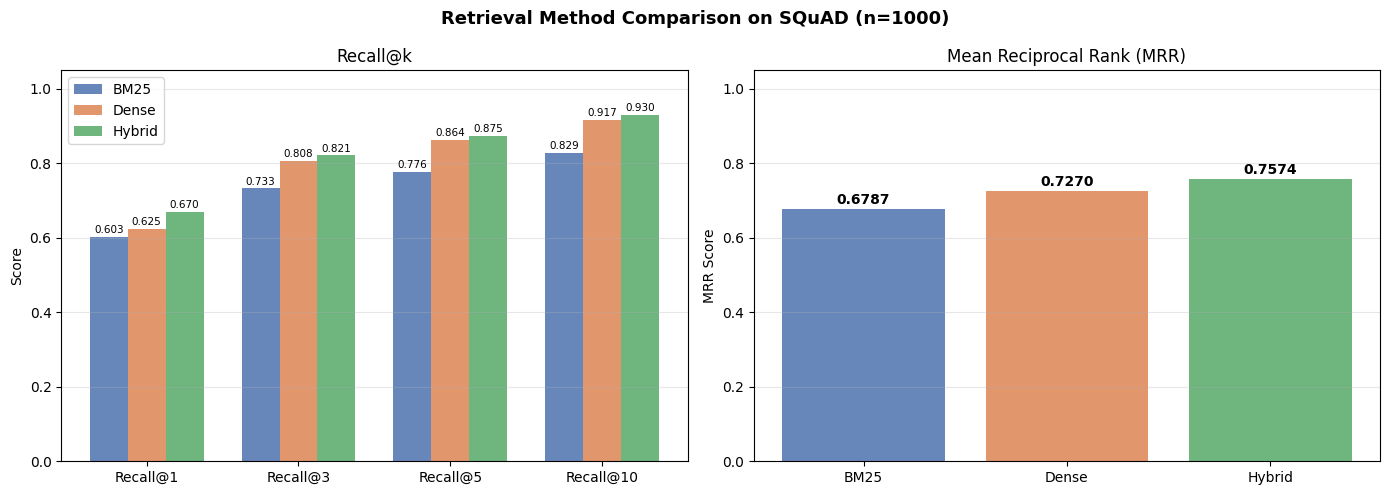

Figure saved as retrieval_comparison.png


In [11]:
COLORS = {'BM25': '#4C72B0', 'Dense': '#DD8452', 'Hybrid': '#55A868'}
methods = list(results_df.index)
recall_cols = [c for c in results_df.columns if 'Recall' in c]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Retrieval Method Comparison on SQuAD (n=1000)', fontsize=13, fontweight='bold')

# --- Recall@k bar chart ---
x = np.arange(len(recall_cols))
width = 0.25
for i, method in enumerate(methods):
    vals = [results_df.loc[method, c] for c in recall_cols]
    bars = axes[0].bar(x + i * width, vals, width, label=method,
                       color=COLORS[method], alpha=0.85)
    for bar, v in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f'{v:.3f}', ha='center', va='bottom', fontsize=7.5)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(recall_cols)
axes[0].set_ylabel('Score')
axes[0].set_title('Recall@k')
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# --- MRR bar chart ---
mrr_vals = [results_df.loc[m, 'MRR'] for m in methods]
bars = axes[1].bar(methods, mrr_vals,
                   color=[COLORS[m] for m in methods], alpha=0.85)
for bar, v in zip(bars, mrr_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

axes[1].set_ylabel('MRR Score')
axes[1].set_title('Mean Reciprocal Rank (MRR)')
axes[1].set_ylim(0, 1.05)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('retrieval_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as retrieval_comparison.png")

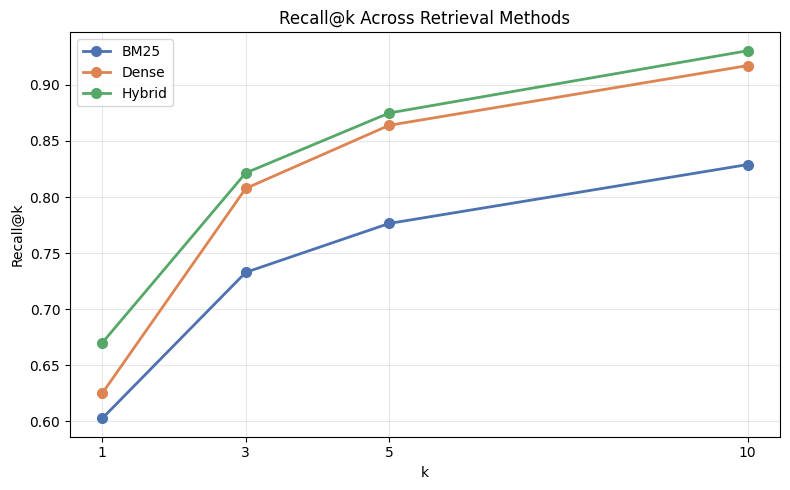

In [12]:
# Recall@k line plot — shows trend across k values
fig, ax = plt.subplots(figsize=(8, 5))

k_nums = [int(c.split('@')[1]) for c in recall_cols]
for method in methods:
    vals = [results_df.loc[method, c] for c in recall_cols]
    ax.plot(k_nums, vals, marker='o', label=method,
            color=COLORS[method], linewidth=2, markersize=7)

ax.set_xlabel('k')
ax.set_ylabel('Recall@k')
ax.set_title('Recall@k Across Retrieval Methods')
ax.set_xticks(k_nums)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('recall_at_k.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Qualitative Analysis — Example Retrievals

In [13]:
def show_example(idx, k=3):
    qa = qa_pairs[idx]
    q = qa['question']
    gold_id = qa['gold_id']

    print(f"Question: {q}")
    print(f"Gold context (id={gold_id}): {contexts[gold_id][:200]}...")
    print()

    for name, fn in [("BM25", retrieve_bm25), ("Dense", retrieve_dense), ("Hybrid", retrieve_hybrid)]:
        top_ids = fn(q, k=k)
        found = gold_id in top_ids
        rank = top_ids.index(gold_id) + 1 if found else None
        status = f"FOUND at rank {rank}" if found else "NOT FOUND"
        print(f"  [{name}] top-{k} ids: {top_ids}  → {status}")

print("=== Example 1 (BM25 likely to succeed — exact keyword match) ===")
show_example(0)

print("\n=== Example 2 ===")
show_example(5)

print("\n=== Example 3 ===")
show_example(10)

=== Example 1 (BM25 likely to succeed — exact keyword match) ===
Question: Which NFL team represented the AFC at Super Bowl 50?
Gold context (id=0): Super Bowl 50 was an American football game to determine the champion of the National Football League (NFL) for the 2015 season. The American Football Conference (AFC) champion Denver Broncos defeated...

  [BM25] top-3 ids: [22, 1, 7]  → NOT FOUND
  [Dense] top-3 ids: [0, 1, 22]  → FOUND at rank 1
  [Hybrid] top-3 ids: [22, 1, 7]  → NOT FOUND

=== Example 2 ===
Question: What was the theme of Super Bowl 50?
Gold context (id=0): Super Bowl 50 was an American football game to determine the champion of the National Football League (NFL) for the 2015 season. The American Football Conference (AFC) champion Denver Broncos defeated...

  [BM25] top-3 ids: [42, 53, 24]  → NOT FOUND
  [Dense] top-3 ids: [0, 4, 35]  → FOUND at rank 1
  [Hybrid] top-3 ids: [42, 0, 3]  → FOUND at rank 2

=== Example 3 ===
Question: What day was the Super Bowl played 

## 9. Summary

| Method | Recall@1 | Recall@3 | Recall@5 | Recall@10 | MRR |
|--------|----------|----------|----------|-----------|-----|
| BM25 | 0.6026 | 0.7328 | 0.7764 | 0.8289 | 0.6787 |
| Dense | 0.6251 | 0.8077 | 0.8640 | 0.9172 | 0.7270 |
| **Hybrid** | **0.6700** | **0.8215** | **0.8749** | **0.9305** | **0.7574** |

*Evaluated on full SQuAD v1.1 validation set: 10,570 questions, 2,067 unique documents.*

**Key findings:**
- Hybrid RRF achieves the best score on **all metrics**, confirming that sparse and dense signals are complementary
- Dense retrieval captures semantic similarity even when exact terms differ — Recall@10 of 0.917 vs BM25's 0.829
- BM25 alone struggles with paraphrased queries due to the vocabulary mismatch problem
- Hybrid improves Recall@1 over BM25 by **+6.7%** and over Dense by **+4.5%**, showing stronger top-1 precision

## Block 2: Chunking Strategy Comparison

Different chunk sizes affect retrieval quality because chunking changes the balance between
context preservation and noise. Smaller chunks can isolate relevant spans more precisely but
may remove useful surrounding context, while larger chunks preserve more information at the
cost of potentially introducing irrelevant text.

This block tests whether increasing chunk size improves retrieval effectiveness for Dense
retrieval, and whether any quality gains justify the larger chunk representations. We compare
three word-count chunk sizes (100 / 200 / 400 words) with 15-word overlap.


In [14]:
CHUNK_SIZES  = [100, 200, 400]   # word counts
EVAL_SUBSET  = qa_pairs[:2000]   # 2 000-question subset for speed

def build_chunk_corpus(contexts, chunk_words, overlap=15):
    chunks, source_ids = [], []
    step = max(1, chunk_words - overlap)
    for ctx_id, ctx in enumerate(contexts):
        words = ctx.split()
        if len(words) <= chunk_words:
            chunks.append(ctx)
            source_ids.append(ctx_id)
        else:
            for start in range(0, len(words) - overlap, step):
                w = words[start:start + chunk_words]
                if len(w) >= 20:
                    chunks.append(' '.join(w))
                    source_ids.append(ctx_id)
    return chunks, np.array(source_ids)

def evaluate_chunk_size(chunk_words, qa_subset, k_values=[1, 3, 5, 10]):
    chunks, src_ids = build_chunk_corpus(contexts, chunk_words)
    embs = encoder.encode(chunks, batch_size=64, normalize_embeddings=True,
                          show_progress_bar=False).astype(np.float32)
    idx = faiss.IndexFlatIP(embs.shape[1])
    idx.add(embs)

    hits = {k: 0 for k in k_values}
    mrr_total = 0.0

    for qa in tqdm(qa_subset, desc=f"chunk={chunk_words}w"):
        q_emb = encoder.encode([qa['question']], normalize_embeddings=True).astype(np.float32)
        _, top_ids = idx.search(q_emb, max(k_values) * 3)

        seen, doc_ids = set(), []
        for cid in top_ids[0]:
            did = int(src_ids[cid])
            if did not in seen:
                seen.add(did)
                doc_ids.append(did)

        gold = qa['gold_id']
        for k in k_values:
            if gold in doc_ids[:k]:
                hits[k] += 1
        if gold in doc_ids[:max(k_values)]:
            mrr_total += 1.0 / (doc_ids.index(gold) + 1)

    n = len(qa_subset)
    metrics = {f"Recall@{k}": hits[k] / n for k in k_values}
    metrics['MRR']        = mrr_total / n
    metrics['Num Chunks'] = len(chunks)
    return metrics

chunk_results = {f"{cs}w": evaluate_chunk_size(cs, EVAL_SUBSET) for cs in CHUNK_SIZES}
chunk_df = pd.DataFrame(chunk_results).T

print("\n=== Chunking Strategy Results (Dense retrieval, n=2000) ===")
print(chunk_df.round(4).to_string())
print("\nBest chunk size per metric:")
for col in [c for c in chunk_df.columns if 'Recall' in c or c == 'MRR']:
    best = chunk_df[col].idxmax()
    print(f"  {col}: {best} ({chunk_df.loc[best, col]:.4f})")

chunk=400w: 100%|██████████| 2000/2000 [00:46<00:00, 43.00it/s]


=== Chunking Strategy Results (Dense retrieval, n=2000) ===
      Recall@1  Recall@3  Recall@5  Recall@10     MRR  Num Chunks
100w    0.5675    0.7805    0.8535     0.9170  0.6897      3496.0
200w    0.5820    0.7860    0.8570     0.9195  0.6984      2203.0
400w    0.5870    0.7875    0.8585     0.9210  0.7015      2076.0

Best chunk size per metric:
  Recall@1: 400w (0.5870)
  Recall@3: 400w (0.7875)
  Recall@5: 400w (0.8585)
  Recall@10: 400w (0.9210)
  MRR: 400w (0.7015)


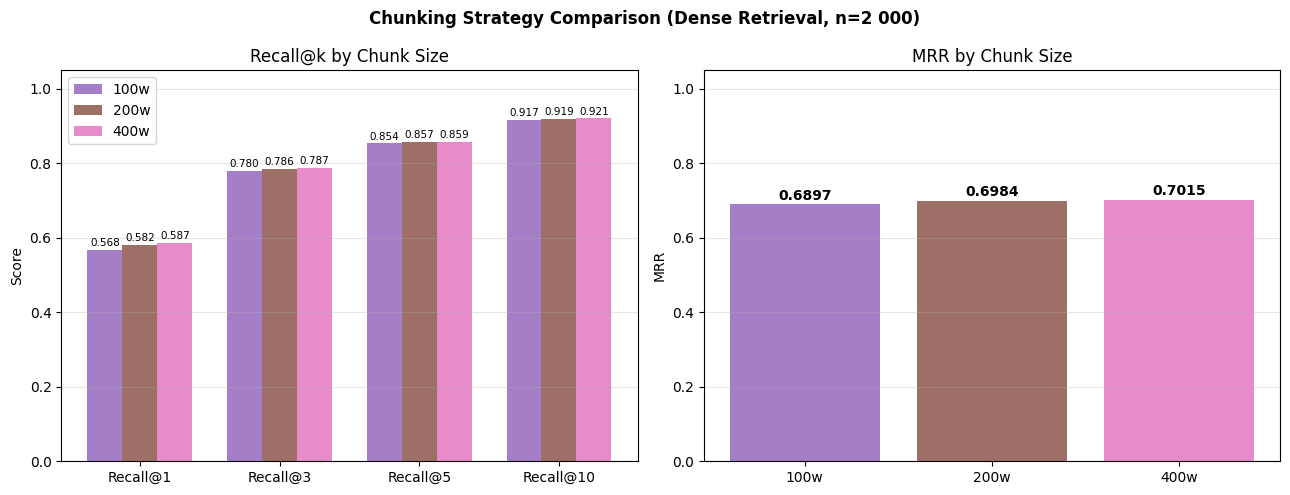

In [15]:
# Visualise chunking results
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Chunking Strategy Comparison (Dense Retrieval, n=2 000)', fontsize=12, fontweight='bold')

chunk_colors = ['#9467bd', '#8c564b', '#e377c2']
recall_cols  = [c for c in chunk_df.columns if 'Recall' in c]
x, w = np.arange(len(recall_cols)), 0.25

for i, (cs, color) in enumerate(zip(chunk_df.index, chunk_colors)):
    vals = chunk_df.loc[cs, recall_cols].values
    bars = axes[0].bar(x + i*w, vals, w, label=cs, color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                     f'{v:.3f}', ha='center', va='bottom', fontsize=7.5)

axes[0].set_xticks(x + w); axes[0].set_xticklabels(recall_cols)
axes[0].set_ylabel('Score'); axes[0].set_title('Recall@k by Chunk Size')
axes[0].set_ylim(0, 1.05); axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

mrr_vals = chunk_df['MRR'].values
bars = axes[1].bar(chunk_df.index, mrr_vals, color=chunk_colors, alpha=0.85)
for bar, v in zip(bars, mrr_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

axes[1].set_ylabel('MRR'); axes[1].set_title('MRR by Chunk Size')
axes[1].set_ylim(0, 1.05); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('chunking_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Block 2 Takeaway

Across this 2,000-question subset, larger chunks consistently perform slightly better than
smaller chunks. The 400-word setting achieves the best Recall@1, Recall@3, Recall@5,
Recall@10, and MRR, suggesting that preserving more local context is beneficial for this
dataset. However, the improvements are modest, indicating that chunk size should be tuned
as a quality-versus-efficiency design choice rather than treated as a universally dominant factor.


## Block 3: Embedding Model Comparison

The choice of bi-encoder affects both retrieval quality and computational cost. A stronger
encoder may improve semantic matching, but larger models also increase encoding time and make
the pipeline more expensive to deploy in limited-resource environments such as free Colab.

This block compares three sentence-transformer models on Dense retrieval using a 2,000-question
subset in order to examine the trade-off between effectiveness and efficiency.

| Model | Size | Notes |
|-------|------|-------|
| all-MiniLM-L6-v2 | ~22 M | Fast, already used in Block 1 |
| all-mpnet-base-v2 | ~110 M | Higher quality, slower |
| bge-small-en-v1.5 | ~33 M | BAAI's efficient retrieval model |


In [16]:
import gc, time

EMBEDDING_MODELS = [
    ('MiniLM-L6',  'sentence-transformers/all-MiniLM-L6-v2'),
    ('mpnet-base', 'sentence-transformers/all-mpnet-base-v2'),
    ('bge-small',  'BAAI/bge-small-en-v1.5'),
]

def evaluate_embedding_model(display_name, model_name, qa_subset, k_values=[1, 3, 5, 10]):
    print(f"\nLoading {display_name}...")
    model = SentenceTransformer(model_name)

    t0   = time.time()
    embs = model.encode(contexts, batch_size=32, normalize_embeddings=True,
                        show_progress_bar=False).astype(np.float32)
    encode_time = round(time.time() - t0, 1)

    idx = faiss.IndexFlatIP(embs.shape[1])
    idx.add(embs)

    hits = {k: 0 for k in k_values}
    mrr_total = 0.0

    for qa in tqdm(qa_subset, desc=display_name):
        q_emb = model.encode([qa['question']], normalize_embeddings=True).astype(np.float32)
        _, ids = idx.search(q_emb, max(k_values))
        gold      = qa['gold_id']
        retrieved = ids[0].tolist()
        for k in k_values:
            if gold in retrieved[:k]:
                hits[k] += 1
        if gold in retrieved:
            mrr_total += 1.0 / (retrieved.index(gold) + 1)

    n = len(qa_subset)
    metrics = {f"Recall@{k}": hits[k] / n for k in k_values}
    metrics['MRR']       = mrr_total / n
    metrics['Encode(s)'] = encode_time
    metrics['Dim']       = int(embs.shape[1])

    del model, embs, idx; gc.collect()
    return metrics

model_results = {
    name: evaluate_embedding_model(name, mpath, EVAL_SUBSET)
    for name, mpath in EMBEDDING_MODELS
}
model_df = pd.DataFrame(model_results).T

print("\n=== Embedding Model Comparison (Dense retrieval, n=2000) ===")
print(model_df.round(4).to_string())


Loading MiniLM-L6...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
MiniLM-L6: 100%|██████████| 2000/2000 [00:44<00:00, 44.59it/s]



Loading mpnet-base...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

bge-small: 100%|██████████| 2000/2000 [01:23<00:00, 23.93it/s]



=== Embedding Model Comparison (Dense retrieval, n=2000) ===
            Recall@1  Recall@3  Recall@5  Recall@10     MRR  Encode(s)    Dim
MiniLM-L6      0.587    0.7875    0.8590      0.921  0.7015      201.8  384.0
mpnet-base     0.613    0.8260    0.8905      0.944  0.7303     1634.5  768.0
bge-small      0.628    0.8185    0.8765      0.922  0.7320      430.4  384.0


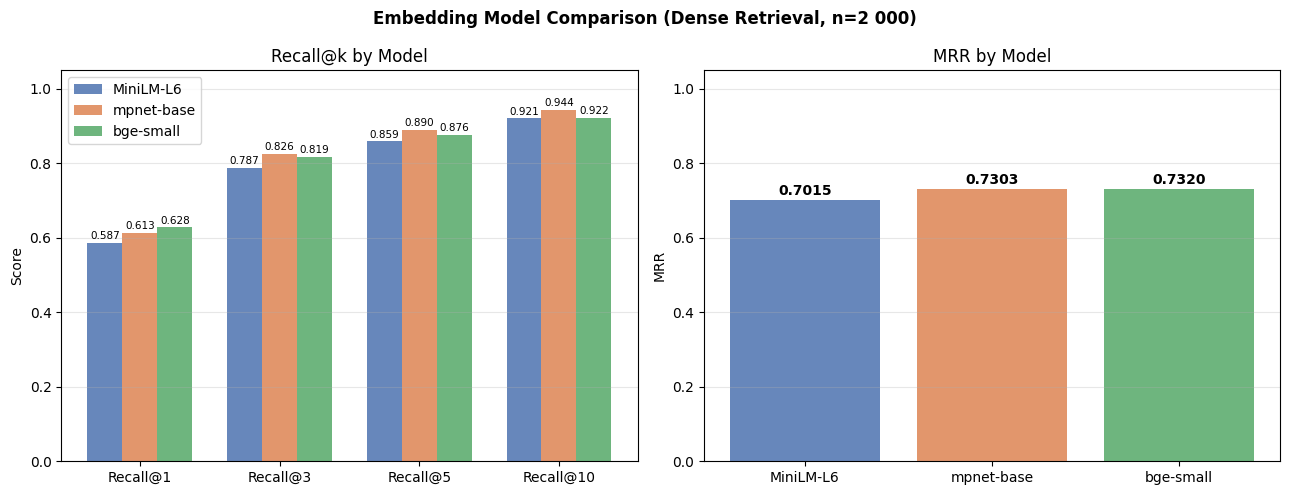

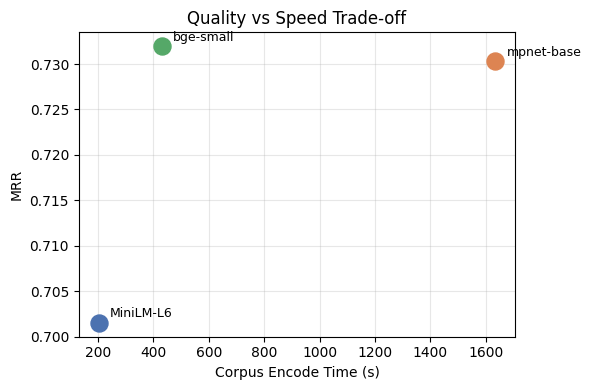

In [17]:
# Visualise model comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Embedding Model Comparison (Dense Retrieval, n=2 000)', fontsize=12, fontweight='bold')

model_colors = ['#4C72B0', '#DD8452', '#55A868']
recall_cols  = [c for c in model_df.columns if 'Recall' in c]
x, w = np.arange(len(recall_cols)), 0.25

for i, (m, color) in enumerate(zip(model_df.index, model_colors)):
    vals = model_df.loc[m, recall_cols].values
    bars = axes[0].bar(x + i*w, vals, w, label=m, color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                     f'{v:.3f}', ha='center', va='bottom', fontsize=7.5)

axes[0].set_xticks(x + w); axes[0].set_xticklabels(recall_cols)
axes[0].set_ylabel('Score'); axes[0].set_title('Recall@k by Model')
axes[0].set_ylim(0, 1.05); axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

mrr_vals = model_df['MRR'].values
bars = axes[1].bar(model_df.index, mrr_vals, color=model_colors, alpha=0.85)
for bar, v in zip(bars, mrr_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

axes[1].set_ylabel('MRR'); axes[1].set_title('MRR by Model')
axes[1].set_ylim(0, 1.05); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Encode time vs MRR scatter
fig2, ax2 = plt.subplots(figsize=(6, 4))
for i, m in enumerate(model_df.index):
    ax2.scatter(model_df.loc[m, 'Encode(s)'], model_df.loc[m, 'MRR'],
                s=150, color=model_colors[i], label=m, zorder=3)
    ax2.annotate(m, (model_df.loc[m, 'Encode(s)'], model_df.loc[m, 'MRR']),
                 textcoords="offset points", xytext=(8, 4), fontsize=9)
ax2.set_xlabel('Corpus Encode Time (s)')
ax2.set_ylabel('MRR')
ax2.set_title('Quality vs Speed Trade-off')
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('model_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

### Block 3 Takeaway

The model comparison highlights a clear effectiveness-efficiency trade-off. Larger encoders
can improve retrieval quality, but they also require substantially more computation time.
This result supports the practical motivation for comparing multiple embedding models instead
of assuming that the strongest model is automatically the most suitable choice for deployment.


## Block 4: Error Analysis

Aggregate metrics show which method performs best overall, but they do not explain why one
retriever succeeds where another fails. To better understand retrieval behaviour, this block
analyses per-question outcomes and groups questions by which retriever(s) returned the gold
document in the top-10 results.

The goal is to identify patterns such as vocabulary mismatch, semantic matching advantages,
and cases where all methods still fail.


In [18]:
ANALYSIS_SUBSET = qa_pairs[:2000]

per_q = []
for qa in tqdm(ANALYSIS_SUBSET, desc="Per-question analysis"):
    gold = qa['gold_id']
    q    = qa['question']
    b    = retrieve_bm25(q,   k=10)
    d    = retrieve_dense(q,  k=10)
    h    = retrieve_hybrid(q, k=10)
    per_q.append({
        'question':   q,
        'gold_id':    gold,
        'bm25_hit':   gold in b,
        'dense_hit':  gold in d,
        'hybrid_hit': gold in h,
        'bm25_rank':  b.index(gold) + 1 if gold in b else None,
        'dense_rank': d.index(gold) + 1 if gold in d else None,
        'hybrid_rank':h.index(gold) + 1 if gold in h else None,
    })

df_pq = pd.DataFrame(per_q)

def categorize(row):
    b, d, h = row['bm25_hit'], row['dense_hit'], row['hybrid_hit']
    if b and d and h:   return 'All Correct'
    if not any([b,d,h]):return 'All Failed'
    if h and not b and not d: return 'Hybrid Only'
    if d and not b and not h: return 'Dense Only'
    if b and not d and not h: return 'BM25 Only'
    if h and d and not b:     return 'Dense+Hybrid'
    if h and b and not d:     return 'BM25+Hybrid'
    return 'Other'

df_pq['category'] = df_pq.apply(categorize, axis=1)
cat_counts = df_pq['category'].value_counts()

print("=== Error Analysis: Retrieval Outcome Categories (n=2000, @k=10) ===")
print(cat_counts.to_string())
print(f"\nHybrid Recall@10: {df_pq['hybrid_hit'].mean():.4f}")
print(f"Dense  Recall@10: {df_pq['dense_hit'].mean():.4f}")
print(f"BM25   Recall@10: {df_pq['bm25_hit'].mean():.4f}")

Per-question analysis: 100%|██████████| 2000/2000 [02:12<00:00, 15.13it/s]

=== Error Analysis: Retrieval Outcome Categories (n=2000, @k=10) ===
category
All Correct     1456
Dense+Hybrid     264
Dense Only       122
BM25+Hybrid       72
All Failed        69
BM25 Only          9
Hybrid Only        8

Hybrid Recall@10: 0.9000
Dense  Recall@10: 0.9210
BM25   Recall@10: 0.7685


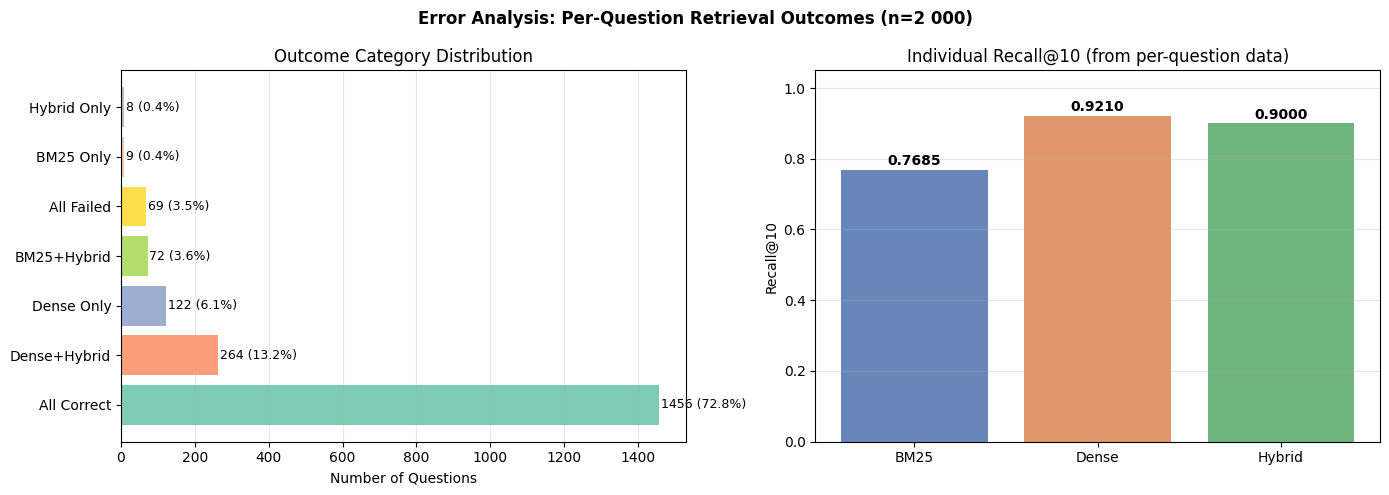

In [19]:
# Visualise error categories
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Error Analysis: Per-Question Retrieval Outcomes (n=2 000)', fontsize=12, fontweight='bold')

cat_order  = cat_counts.index.tolist()
cat_vals   = cat_counts.values
cat_colors = plt.cm.Set2(np.linspace(0, 1, len(cat_order)))

axes[0].barh(cat_order, cat_vals, color=cat_colors, alpha=0.85)
for i, v in enumerate(cat_vals):
    axes[0].text(v + 5, i, f'{v} ({v/len(df_pq)*100:.1f}%)', va='center', fontsize=9)
axes[0].set_xlabel('Number of Questions')
axes[0].set_title('Outcome Category Distribution')
axes[0].grid(axis='x', alpha=0.3)

# Venn-style overlap bar: BM25 / Dense / Hybrid individual hit rates
methods  = ['BM25', 'Dense', 'Hybrid']
hit_cols = ['bm25_hit', 'dense_hit', 'hybrid_hit']
rates    = [df_pq[c].mean() for c in hit_cols]
colors   = ['#4C72B0', '#DD8452', '#55A868']
bars = axes[1].bar(methods, rates, color=colors, alpha=0.85)
for bar, v in zip(bars, rates):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{v:.4f}', ha='center', va='bottom', fontweight='bold')
axes[1].set_ylabel('Recall@10')
axes[1].set_title('Individual Recall@10 (from per-question data)')
axes[1].set_ylim(0, 1.05)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Qualitative examples: where Dense wins but BM25 fails (vocabulary mismatch)
print("=== Cases: Dense succeeds, BM25 fails (vocabulary mismatch) ===")
dense_wins = df_pq[(df_pq['dense_hit']) & (~df_pq['bm25_hit'])].head(3)
for _, row in dense_wins.iterrows():
    print(f"  Q: {row['question']}")
    print(f"     Dense rank={row['dense_rank']}  BM25=MISS")
    print(f"     Gold ctx: {contexts[row['gold_id']][:120]}...\n")

print("=== Cases: BM25 succeeds, Dense fails (exact term match) ===")
bm25_wins = df_pq[(df_pq['bm25_hit']) & (~df_pq['dense_hit'])].head(3)
for _, row in bm25_wins.iterrows():
    print(f"  Q: {row['question']}")
    print(f"     BM25 rank={row['bm25_rank']}  Dense=MISS")
    print(f"     Gold ctx: {contexts[row['gold_id']][:120]}...\n")

print("=== Cases: All methods fail ===")
all_fail = df_pq[~df_pq['bm25_hit'] & ~df_pq['dense_hit'] & ~df_pq['hybrid_hit']].head(3)
for _, row in all_fail.iterrows():
    print(f"  Q: {row['question']}")
    print(f"     Gold ctx: {contexts[row['gold_id']][:120]}...\n")

=== Cases: Dense succeeds, BM25 fails (vocabulary mismatch) ===
  Q: Which NFL team represented the AFC at Super Bowl 50?
     Dense rank=1.0  BM25=MISS
     Gold ctx: Super Bowl 50 was an American football game to determine the champion of the National Football League (NFL) for the 2015...

  Q: Which NFL team represented the NFC at Super Bowl 50?
     Dense rank=1.0  BM25=MISS
     Gold ctx: Super Bowl 50 was an American football game to determine the champion of the National Football League (NFL) for the 2015...

  Q: Which NFL team won Super Bowl 50?
     Dense rank=1.0  BM25=MISS
     Gold ctx: Super Bowl 50 was an American football game to determine the champion of the National Football League (NFL) for the 2015...

=== Cases: BM25 succeeds, Dense fails (exact term match) ===
  Q: What position does Von Miller play?
     BM25 rank=1.0  Dense=MISS
     Gold ctx: The Broncos took an early lead in Super Bowl 50 and never trailed. Newton was limited by Denver's defense, which sacked 

### Block 4 Takeaway

The error analysis shows that retrieval failures are not evenly distributed across methods.
Dense and Hybrid retrieval recover many cases that BM25 misses, which is consistent with the
vocabulary mismatch problem. At the same time, a small number of BM25-only successes show that
exact lexical matching still matters, while all-failed cases indicate that some questions remain
challenging regardless of retrieval strategy.
